# Posterior for local recombination rate using SBI

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import Phylo
import torch
from torch.distributions import Uniform
from sbi.utils.user_input_checks import MultipleIndependent
from sbi.inference import NPE_C
from sbi.analysis import plot_summary
import sys
sys.path.append('../pysimARG')
from clonal_genealogy import ClonalTree
from newick_to_tree import newick_to_tree
from discrete_uniform import DiscreteUniform

torch_device = "cpu"

c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


## Load simulation data

Load genome data and clonal tree.

In [2]:
genome_simbac = np.loadtxt("../data/SimBac/genomes_bool.csv", delimiter=",", dtype=bool)

In [3]:
genome_simbac.shape

(30, 1000000)

In [4]:
np.random.seed(100)
clonal_tree = ClonalTree(n=30)

# Load phylo tree and convert to ClonalTree format
phylo_tree = Phylo.read("../data/SimBac/clonal_frame.nwk", "newick")
Phylo.draw_ascii(phylo_tree)

edge, node_height = newick_to_tree(phylo_tree)
clonal_tree.edge = edge
clonal_tree.node_height = node_height
clonal_tree.height = np.max(node_height)
clonal_tree.length = np.sum(edge[:, 2])

                                                                    ____ 14
                                                                   |
                                                                   |    , 15
                                                        ___________|   _|
                                                       |           |  | , 5
                                                       |           |  | |
                                                       |           |__| | 24
                                                       |              |
                                                       |              | , 27
                                                       |              |_|
                                                       |                | 4
                                                       |
                                                       |      __________ 18
                                             

## Summary statistics

### Get summary statistics from SimBac data

In [5]:
x_500_mat = np.loadtxt("../data/x_500_mat.csv", delimiter=",")
x_2000_mat = np.loadtxt("../data/x_2000_mat.csv", delimiter=",")
x_6000_mat = np.loadtxt("../data/x_6000_mat.csv", delimiter=",")

x_o_500 = torch.tensor(x_500_mat[0, :], device=torch_device)
x_o_500 = x_o_500.to(torch.float32)

x_o_2000 = torch.tensor(x_2000_mat[0, :], device=torch_device)
x_o_2000 = x_o_2000.to(torch.float32)

x_o_6000 = torch.tensor(x_6000_mat[0, :], device=torch_device)
x_o_6000 = x_o_6000.to(torch.float32)

x_o_500.shape, x_o_2000.shape, x_o_6000.shape

(torch.Size([46]), torch.Size([46]), torch.Size([46]))

### Load simulations from ClonalOrigin model

In [6]:
x_o_ClonalOrigin = np.loadtxt("../data/x_o_ClonalOrigin.csv", delimiter=",")

CO_x_500 = torch.tensor(x_o_ClonalOrigin[0, :], device=torch_device)
CO_x_500 = CO_x_500.to(torch.float32)

CO_x_2000 = torch.tensor(x_o_ClonalOrigin[1, :], device=torch_device)
CO_x_2000 = CO_x_2000.to(torch.float32)

CO_x_6000 = torch.tensor(x_o_ClonalOrigin[2, :], device=torch_device)
CO_x_6000 = CO_x_6000.to(torch.float32)

CO_x_500.shape, CO_x_2000.shape, CO_x_6000.shape

(torch.Size([46]), torch.Size([46]), torch.Size([46]))

In [7]:
theta1 = np.loadtxt('../data/theta1.csv', delimiter=",")
x1 = np.loadtxt('../data/x1.csv', delimiter=",")

theta2 = np.loadtxt('../data/theta2.csv', delimiter=",")
x2 = np.loadtxt('../data/x2.csv', delimiter=",")

x = np.vstack([x1, x2])
theta = np.vstack([theta1, theta2])

print(theta.shape, x.shape)

(20000, 2) (20000, 46)


In [8]:
theta = torch.tensor(theta, device=torch_device)
theta = theta.to(torch.float32)
theta_numpy = theta.cpu().numpy()

x = torch.tensor(x, device=torch_device)
x = x.to(torch.float32)
x_numpy = x.cpu().numpy()

In [9]:
for i in range(x.shape[1]):
    col_min = torch.min(x[:, i])
    col_max = torch.max(x[:, i])
    sb_500 = x_o_500[i]
    sb_2000 = x_o_2000[i]
    sb_6000 = x_o_6000[i]
    co_500 = CO_x_500[i]
    co_2000 = CO_x_2000[i]
    co_6000 = CO_x_6000[i]

    if sb_500 < col_min or sb_500 > col_max:
        print(f"Summary statistic {i} for N=500 is out of simulation range.")

    if sb_2000 < col_min or sb_2000 > col_max:
        print(f"Summary statistic {i} for N=2000 is out of simulation range.")
    
    if sb_6000 < col_min or sb_6000 > col_max:
        print(f"Summary statistic {i} for N=6000 is out of simulation range.")
    
    if co_500 < col_min or co_500 > col_max:
        print(f"Summary statistic {i} for ClonalOrigin N=500 is out of simulation range.")
    
    if co_2000 < col_min or co_2000 > col_max:
        print(f"Summary statistic {i} for ClonalOrigin N=2000 is out of simulation range.")

    if co_6000 < col_min or co_6000 > col_max:
        print(f"Summary statistic {i} for ClonalOrigin N=6000 is out of simulation range.")

Summary statistic 0 for N=2000 is out of simulation range.
Summary statistic 0 for N=6000 is out of simulation range.
Summary statistic 1 for N=2000 is out of simulation range.
Summary statistic 1 for N=6000 is out of simulation range.
Summary statistic 16 for N=2000 is out of simulation range.
Summary statistic 16 for N=6000 is out of simulation range.
Summary statistic 17 for N=2000 is out of simulation range.
Summary statistic 17 for N=6000 is out of simulation range.
Summary statistic 24 for N=2000 is out of simulation range.
Summary statistic 24 for N=6000 is out of simulation range.
Summary statistic 25 for N=2000 is out of simulation range.
Summary statistic 25 for N=6000 is out of simulation range.


## NPE

### Create prior to pass range knowledge to NPE

In [10]:
prior_rho = Uniform(low=torch.tensor([0.0]), high=torch.tensor([0.1]))
prior_L = DiscreteUniform(low=torch.tensor([100.0]), high=torch.tensor([10000.0]))

prior = MultipleIndependent(
    dists=[prior_rho, prior_L],
    validate_args=False,
    device=torch_device
)

### Using simulation of exact LD and G4 counts

In [11]:
seed = 100
num_posterior_samples=1000
learning_rate = 0.0005

inference1 = NPE_C(prior=prior, density_estimator="nsf", device=torch_device)
torch.manual_seed(seed)
np.random.seed(seed)

In [13]:
exact_col = list(range(2, 8)) + list(range(18, 24)) + list(range(32, 46))
x1 = x[:, exact_col]

x1.shape, x1.dtype

(torch.Size([20000, 26]), torch.float32)

In [14]:
density_estimator1 = inference1.append_simulations(theta, x1).train(
    max_num_epochs=500, learning_rate=learning_rate
)
posterior1 = inference1.build_posterior(density_estimator1)

 Neural network successfully converged after 106 epochs.

For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=c:\Users\u2008181\likelihood-free\python\sbi-logs\NPE_C\2026-06-03T11_48_15.445852' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.

Valid tags are: ['best_validation_loss', 'epoch_durations_sec', 'epochs_trained', 'training_loss', 'validation_loss'].


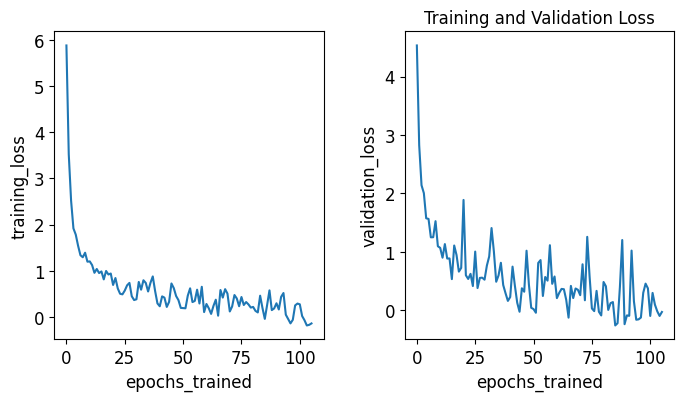

In [15]:
fig, axes = plot_summary(
    inference1, 
    tags=["training_loss", "validation_loss"], 
    figsize=(8, 4)
)
plt.title("Training and Validation Loss")
plt.show()

#### SimBac observations

In [17]:
theta_trained_500 = posterior1.sample((num_posterior_samples,), x=x_o_500[exact_col])
theta_trained_500_numpy = theta_trained_500.cpu().numpy()

1096it [00:00, 29680.00it/s]            


In [18]:
theta_trained_2000 = posterior1.sample((num_posterior_samples,), x=x_o_2000[exact_col])
theta_trained_2000_numpy = theta_trained_2000.cpu().numpy()

100%|██████████| 1000/1000 [00:00<00:00, 33366.78it/s]


In [19]:
theta_trained_6000 = posterior1.sample((num_posterior_samples,), x=x_o_6000[exact_col])
theta_trained_6000_numpy = theta_trained_6000.cpu().numpy()

100%|██████████| 1000/1000 [00:00<00:00, 39130.72it/s]


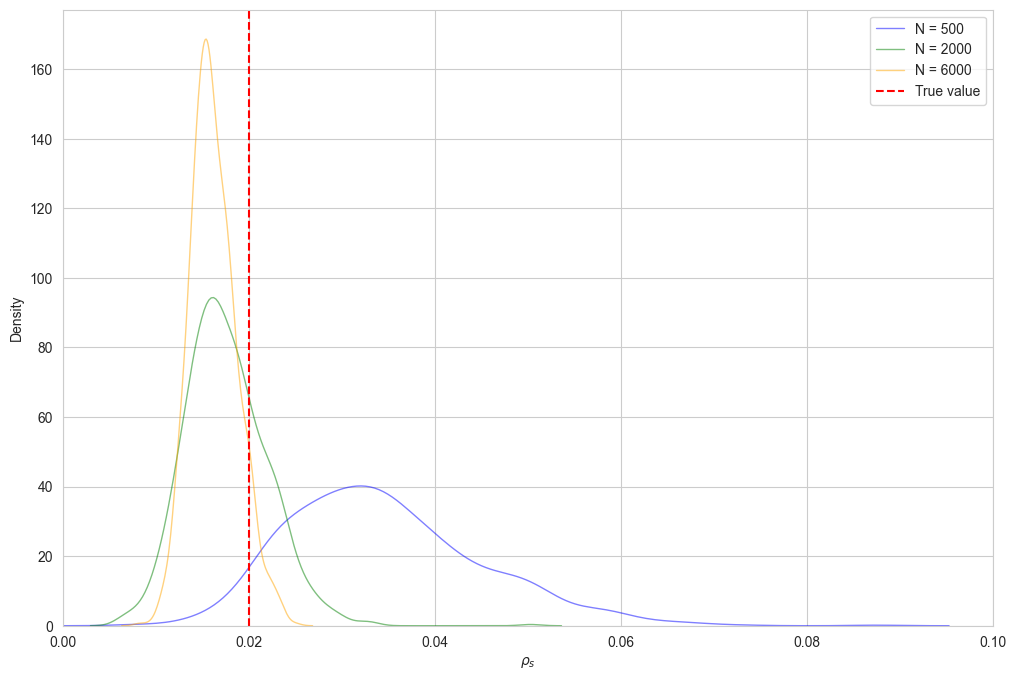

In [20]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta_trained_500_numpy[:, 0], label='N = 500', color='blue', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_2000_numpy[:, 0], label='N = 2000', color='green', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_6000_numpy[:, 0], label='N = 6000', color='orange', linewidth=1, alpha=0.5)
plt.axvline(x=0.02, color='red', linestyle='dashed', label='True value')
plt.xlabel(r'$\rho_s$')
plt.xlim(0.0, 0.1)
plt.legend()
plt.show()

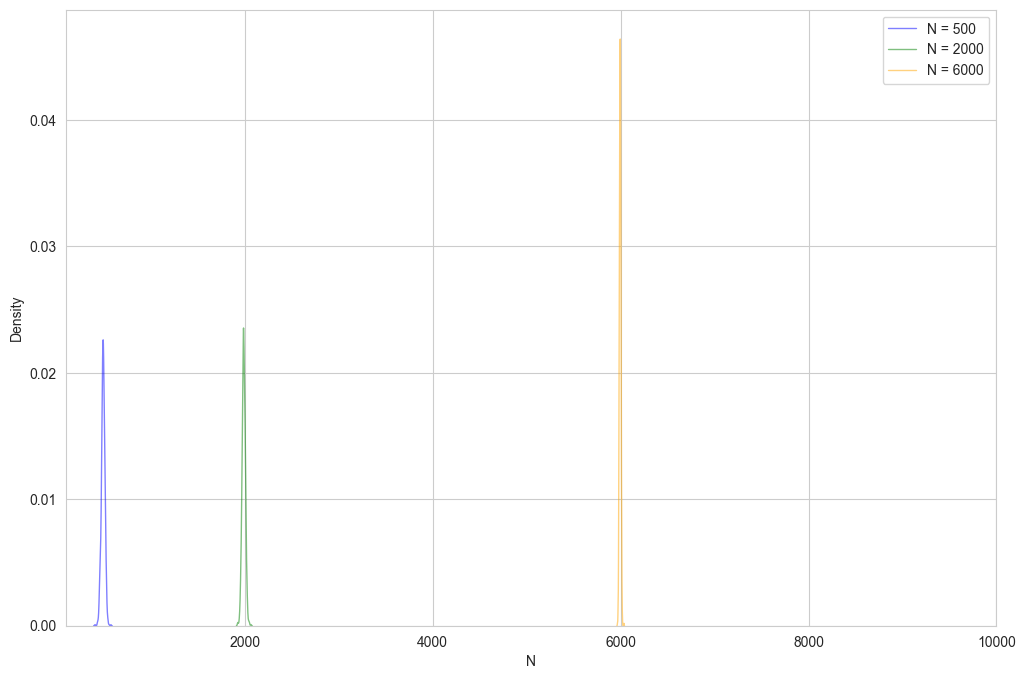

In [21]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta_trained_500_numpy[:, 1], label='N = 500', color='blue', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_2000_numpy[:, 1], label='N = 2000', color='green', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_6000_numpy[:, 1], label='N = 6000', color='orange', linewidth=1, alpha=0.5)
plt.xlabel('N')
plt.xlim(100.0, 10000.0)
plt.legend()
plt.show()

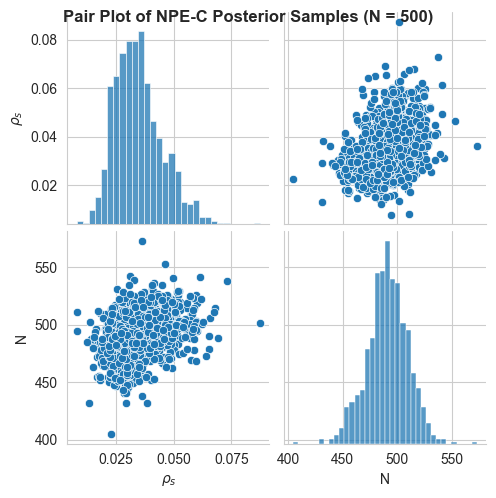

In [22]:
df_500 = pd.DataFrame(theta_trained_500_numpy, columns=[r"$\rho_s$", "N"])
sns.pairplot(df_500)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 500)', fontsize=12, fontweight='bold')
plt.show()

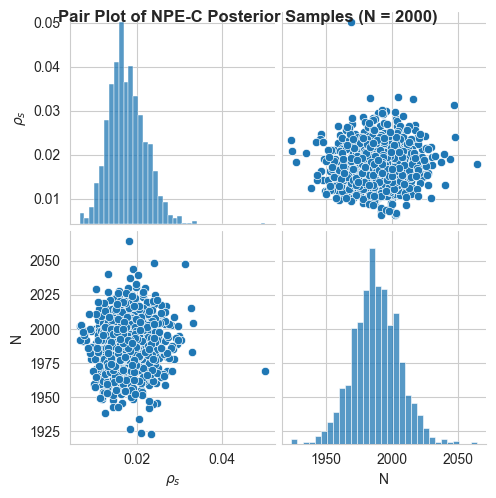

In [23]:
df_2000 = pd.DataFrame(theta_trained_2000_numpy, columns=[r"$\rho_s$", "N"])
sns.pairplot(df_2000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 2000)', fontsize=12, fontweight='bold')
plt.show()

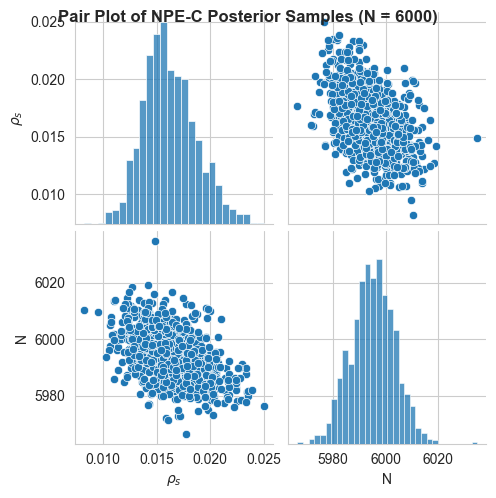

In [24]:
df_6000 = pd.DataFrame(theta_trained_6000_numpy, columns=[r"$\rho_s$", "N"])
sns.pairplot(df_6000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 6000)', fontsize=12, fontweight='bold')
plt.show()

#### ClonalOrigin observations

In [25]:
theta_trained_500 = posterior1.sample((num_posterior_samples,), x=CO_x_500[exact_col])
theta_trained_500_numpy = theta_trained_500.cpu().numpy()

1097it [00:00, 29089.54it/s]            


In [26]:
theta_trained_2000 = posterior1.sample((num_posterior_samples,), x=CO_x_2000[exact_col])
theta_trained_2000_numpy = theta_trained_2000.cpu().numpy()

1097it [00:00, 23855.00it/s]            


In [27]:
theta_trained_6000 = posterior1.sample((num_posterior_samples,), x=CO_x_6000[exact_col])
theta_trained_6000_numpy = theta_trained_6000.cpu().numpy()

1099it [00:00, 31918.93it/s]            


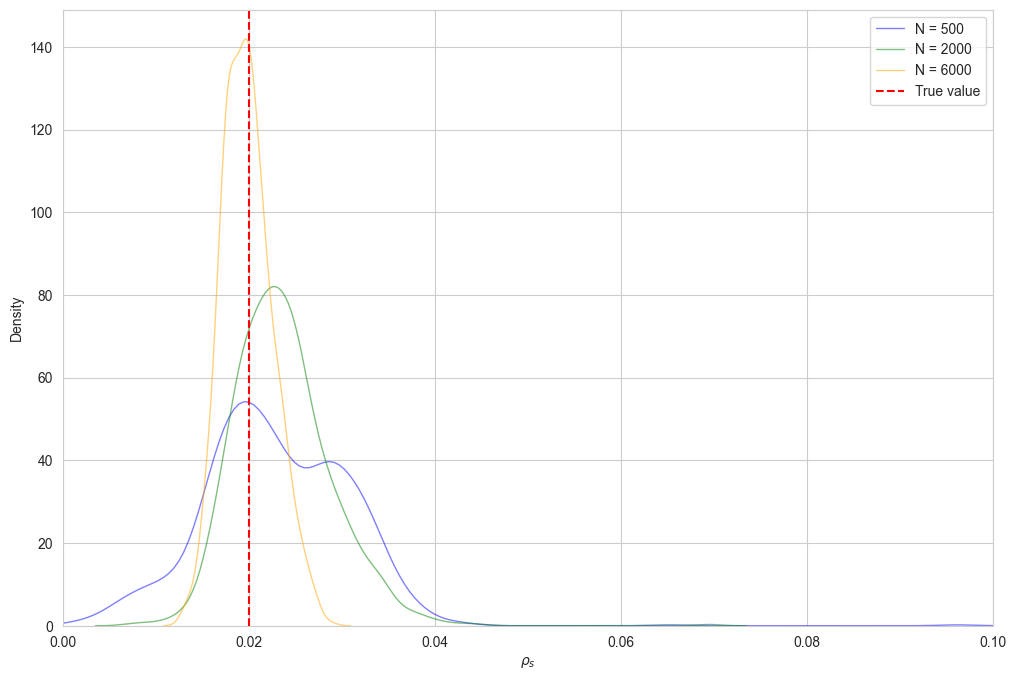

In [28]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta_trained_500_numpy[:, 0], label='N = 500', color='blue', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_2000_numpy[:, 0], label='N = 2000', color='green', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_6000_numpy[:, 0], label='N = 6000', color='orange', linewidth=1, alpha=0.5)
plt.axvline(x=0.02, color='red', linestyle='dashed', label='True value')
plt.xlabel(r'$\rho_s$')
plt.xlim(0.0, 0.1)
plt.legend()
plt.show()

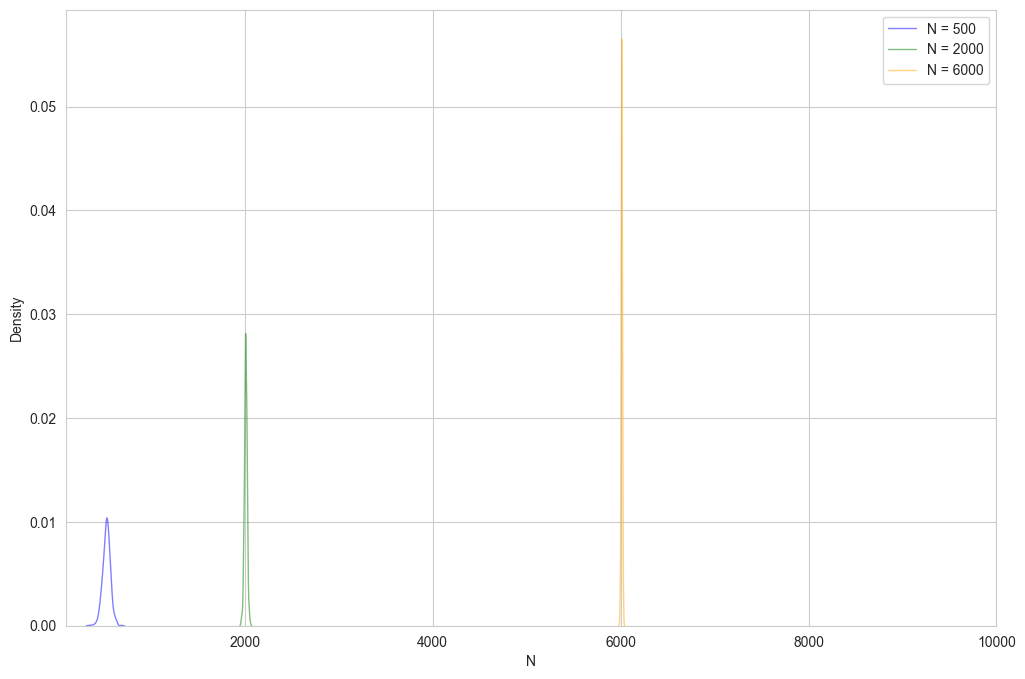

In [29]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta_trained_500_numpy[:, 1], label='N = 500', color='blue', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_2000_numpy[:, 1], label='N = 2000', color='green', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_6000_numpy[:, 1], label='N = 6000', color='orange', linewidth=1, alpha=0.5)
plt.xlabel('N')
plt.xlim(100.0, 10000.0)
plt.legend()
plt.show()

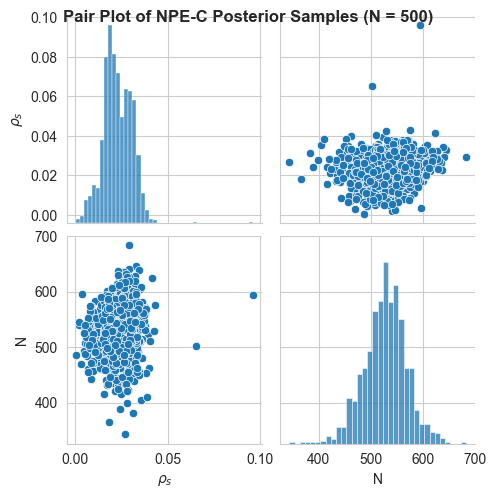

In [30]:
df_500 = pd.DataFrame(theta_trained_500_numpy, columns=[r"$\rho_s$", "N"])
sns.pairplot(df_500)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 500)', fontsize=12, fontweight='bold')
plt.show()

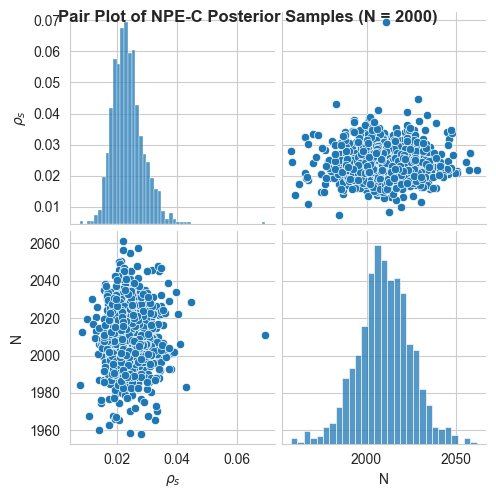

In [31]:
df_2000 = pd.DataFrame(theta_trained_2000_numpy, columns=[r"$\rho_s$", "N"])
sns.pairplot(df_2000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 2000)', fontsize=12, fontweight='bold')
plt.show()

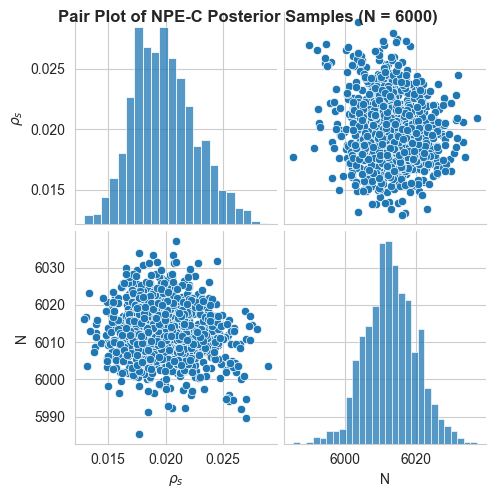

In [32]:
df_6000 = pd.DataFrame(theta_trained_6000_numpy, columns=[r"$\rho_s$", "N"])
sns.pairplot(df_6000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 6000)', fontsize=12, fontweight='bold')
plt.show()

### Using simulation of proportion values

In [36]:
seed = 100
num_posterior_samples=1000
learning_rate = 0.0005

inference2 = NPE_C(prior=prior, density_estimator="nsf", device=torch_device)
torch.manual_seed(seed)
np.random.seed(seed)

In [37]:
prop_col = list(range(10, 16)) + list(range(26, 32)) + list(range(32, 46))
x2 = x[:, prop_col]

x2.shape, x2.dtype

(torch.Size([20000, 26]), torch.float32)

In [38]:
density_estimator2 = inference2.append_simulations(theta, x2).train(
    max_num_epochs=500, learning_rate=learning_rate
)
posterior2 = inference2.build_posterior(density_estimator2)

 Neural network successfully converged after 190 epochs.

For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=c:\Users\u2008181\likelihood-free\python\sbi-logs\NPE_C\2026-06-03T12_08_24.022196' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.

Valid tags are: ['best_validation_loss', 'epoch_durations_sec', 'epochs_trained', 'training_loss', 'validation_loss'].


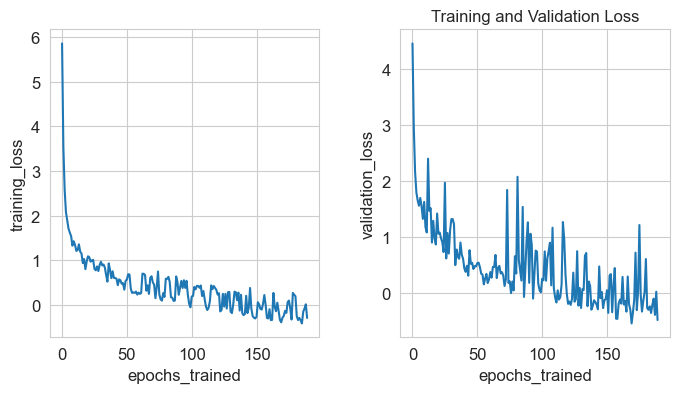

In [39]:
fig, axes = plot_summary(
    inference2, 
    tags=["training_loss", "validation_loss"], 
    figsize=(8, 4)
)
plt.title("Training and Validation Loss")
plt.show()

#### SimBac observations

In [40]:
theta_trained_500 = posterior2.sample((num_posterior_samples,), x=x_o_500[prop_col])
theta_trained_500_numpy = theta_trained_500.cpu().numpy()

1098it [00:00, 26818.61it/s]            


In [41]:
theta_trained_2000 = posterior2.sample((num_posterior_samples,), x=x_o_2000[prop_col])
theta_trained_2000_numpy = theta_trained_2000.cpu().numpy()

100%|██████████| 1000/1000 [00:00<00:00, 35070.90it/s]


In [42]:
theta_trained_6000 = posterior2.sample((num_posterior_samples,), x=x_o_6000[prop_col])
theta_trained_6000_numpy = theta_trained_6000.cpu().numpy()

100%|██████████| 1000/1000 [00:00<00:00, 37166.41it/s]


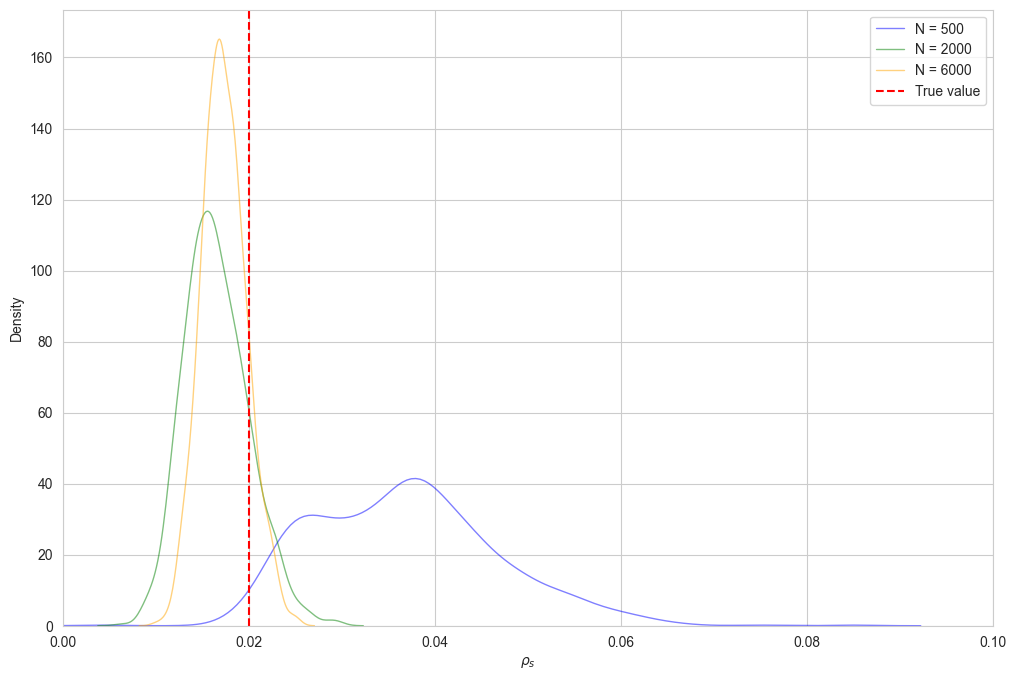

In [43]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta_trained_500_numpy[:, 0], label='N = 500', color='blue', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_2000_numpy[:, 0], label='N = 2000', color='green', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_6000_numpy[:, 0], label='N = 6000', color='orange', linewidth=1, alpha=0.5)
plt.axvline(x=0.02, color='red', linestyle='dashed', label='True value')
plt.xlabel(r'$\rho_s$')
plt.xlim(0.0, 0.1)
plt.legend()
plt.show()

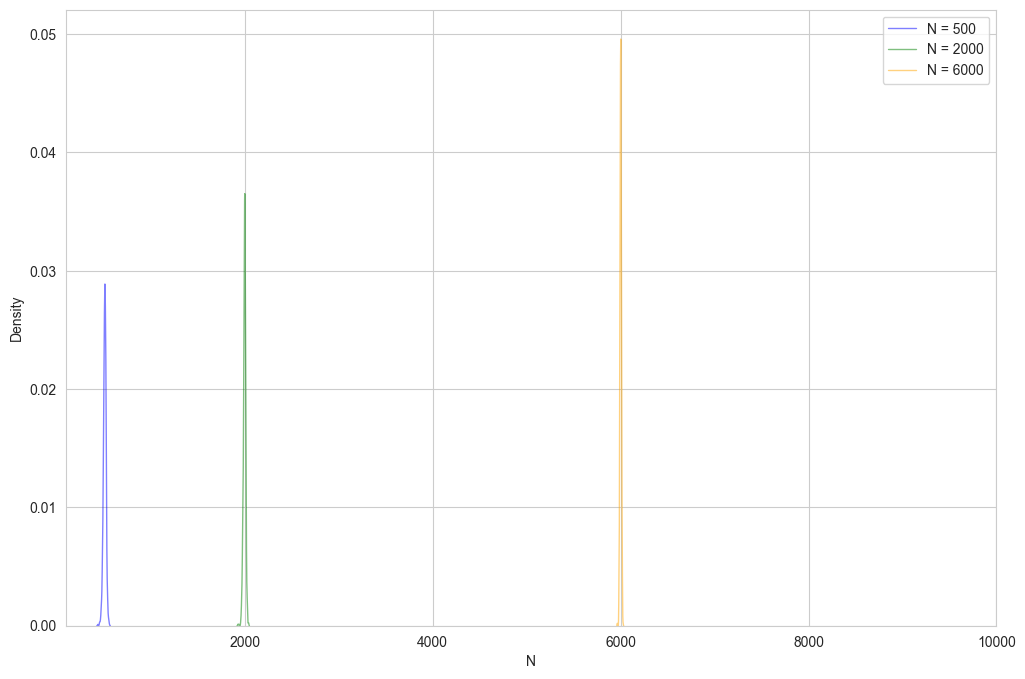

In [44]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta_trained_500_numpy[:, 1], label='N = 500', color='blue', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_2000_numpy[:, 1], label='N = 2000', color='green', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_6000_numpy[:, 1], label='N = 6000', color='orange', linewidth=1, alpha=0.5)
plt.xlabel('N')
plt.xlim(100.0, 10000.0)
plt.legend()
plt.show()

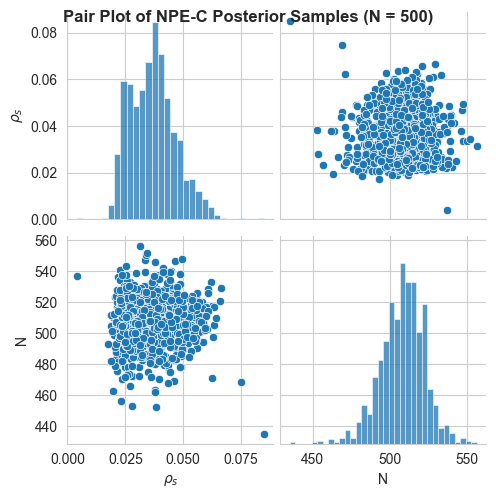

In [45]:
df_500 = pd.DataFrame(theta_trained_500_numpy, columns=[r"$\rho_s$", "N"])
sns.pairplot(df_500)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 500)', fontsize=12, fontweight='bold')
plt.show()

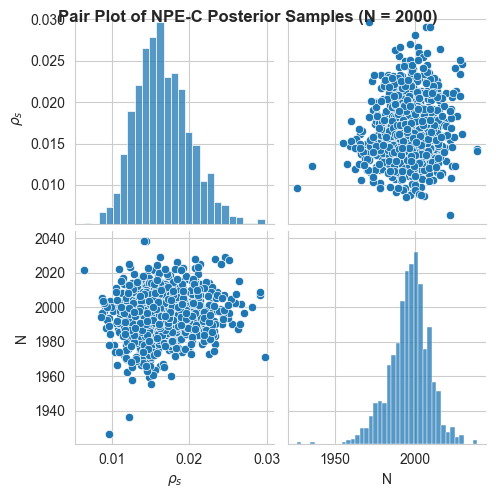

In [46]:
df_2000 = pd.DataFrame(theta_trained_2000_numpy, columns=[r"$\rho_s$", "N"])
sns.pairplot(df_2000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 2000)', fontsize=12, fontweight='bold')
plt.show()

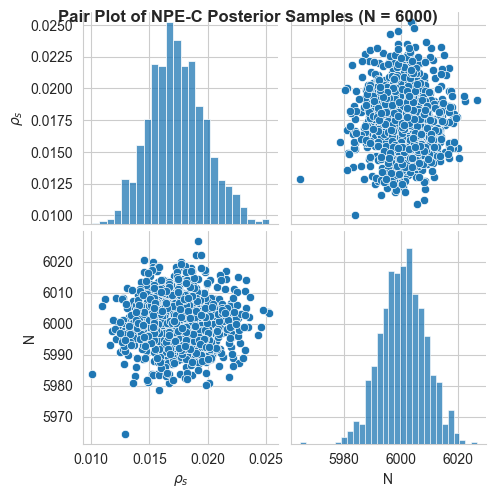

In [47]:
df_6000 = pd.DataFrame(theta_trained_6000_numpy, columns=[r"$\rho_s$", "N"])
sns.pairplot(df_6000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 6000)', fontsize=12, fontweight='bold')
plt.show()

#### ClonalOrigin observations

In [48]:
theta_trained_500 = posterior2.sample((num_posterior_samples,), x=CO_x_500[prop_col])
theta_trained_500_numpy = theta_trained_500.cpu().numpy()

100%|██████████| 1000/1000 [00:00<00:00, 30169.64it/s]


In [49]:
theta_trained_2000 = posterior2.sample((num_posterior_samples,), x=CO_x_2000[prop_col])
theta_trained_2000_numpy = theta_trained_2000.cpu().numpy()

100%|██████████| 1000/1000 [00:00<00:00, 35671.92it/s]


In [50]:
theta_trained_6000 = posterior2.sample((num_posterior_samples,), x=CO_x_6000[prop_col])
theta_trained_6000_numpy = theta_trained_6000.cpu().numpy()

100%|██████████| 1000/1000 [00:00<00:00, 32220.75it/s]


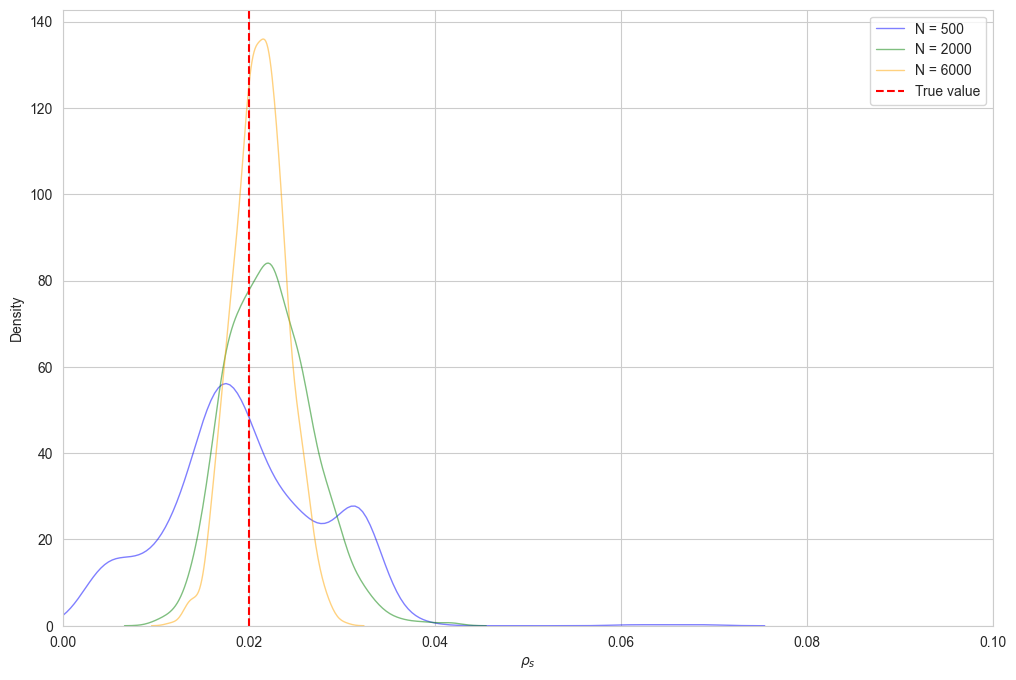

In [51]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta_trained_500_numpy[:, 0], label='N = 500', color='blue', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_2000_numpy[:, 0], label='N = 2000', color='green', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_6000_numpy[:, 0], label='N = 6000', color='orange', linewidth=1, alpha=0.5)
plt.axvline(x=0.02, color='red', linestyle='dashed', label='True value')
plt.xlabel(r'$\rho_s$')
plt.xlim(0.0, 0.1)
plt.legend()
plt.show()

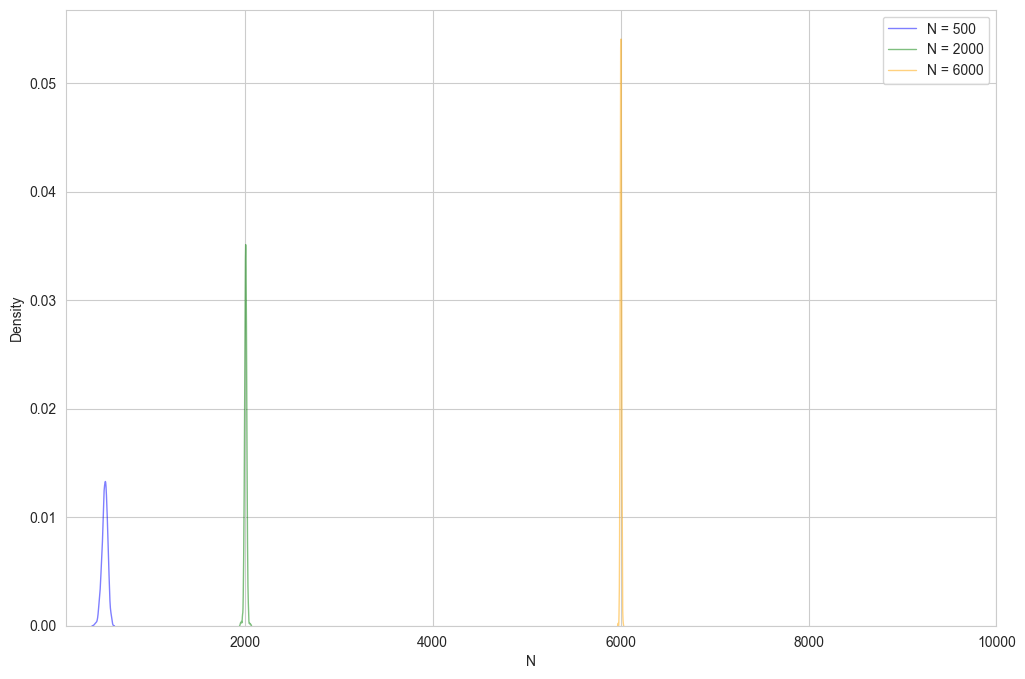

In [52]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta_trained_500_numpy[:, 1], label='N = 500', color='blue', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_2000_numpy[:, 1], label='N = 2000', color='green', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_6000_numpy[:, 1], label='N = 6000', color='orange', linewidth=1, alpha=0.5)
plt.xlabel('N')
plt.xlim(100.0, 10000.0)
plt.legend()
plt.show()

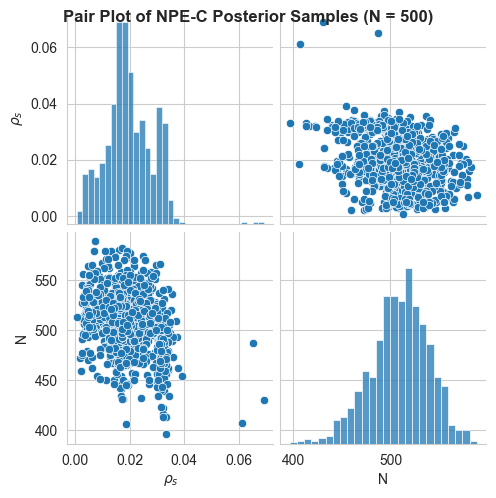

In [53]:
df_500 = pd.DataFrame(theta_trained_500_numpy, columns=[r"$\rho_s$", "N"])
sns.pairplot(df_500)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 500)', fontsize=12, fontweight='bold')
plt.show()

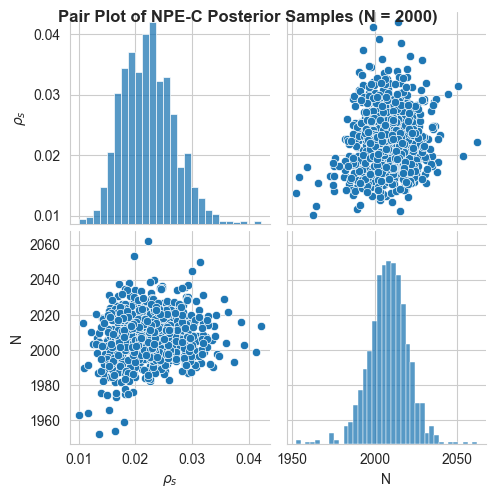

In [54]:
df_2000 = pd.DataFrame(theta_trained_2000_numpy, columns=[r"$\rho_s$", "N"])
sns.pairplot(df_2000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 2000)', fontsize=12, fontweight='bold')
plt.show()

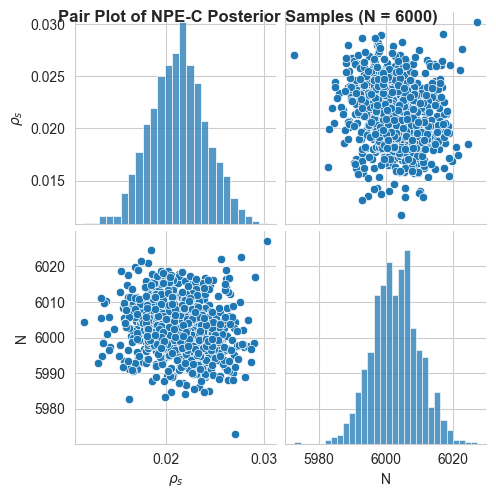

In [55]:
df_6000 = pd.DataFrame(theta_trained_6000_numpy, columns=[r"$\rho_s$", "N"])
sns.pairplot(df_6000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 6000)', fontsize=12, fontweight='bold')
plt.show()

### Using all

In [56]:
seed = 100
num_posterior_samples=1000
learning_rate = 0.0005

inference3 = NPE_C(prior=prior, density_estimator="nsf", device=torch_device)
torch.manual_seed(seed)
np.random.seed(seed)

In [60]:
all_col = np.unique(exact_col + prop_col)
x3 = x[:, all_col]

x3.shape, x3.dtype

(torch.Size([20000, 38]), torch.float32)

In [61]:
density_estimator3 = inference3.append_simulations(theta, x3).train(
    max_num_epochs=500, learning_rate=learning_rate
)
posterior3 = inference3.build_posterior(density_estimator3)

 Neural network successfully converged after 88 epochs.

For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=c:\Users\u2008181\likelihood-free\python\sbi-logs\NPE_C\2026-06-03T12_22_13.613854' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.

Valid tags are: ['best_validation_loss', 'epoch_durations_sec', 'epochs_trained', 'training_loss', 'validation_loss'].


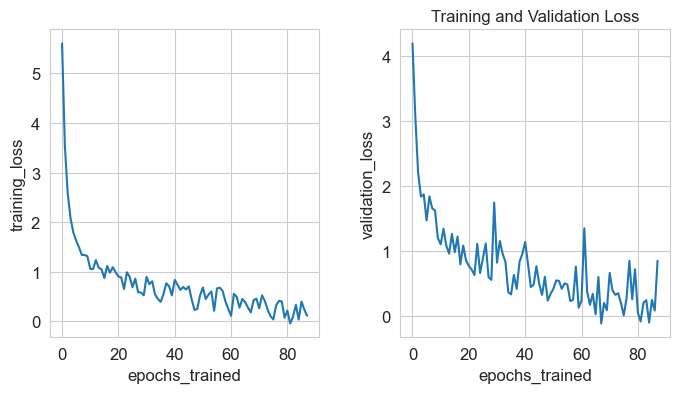

In [62]:
fig, axes = plot_summary(
    inference3, 
    tags=["training_loss", "validation_loss"], 
    figsize=(8, 4)
)
plt.title("Training and Validation Loss")
plt.show()

#### SimBac observations

In [63]:
theta_trained_500 = posterior3.sample((num_posterior_samples,), x=x_o_500[all_col])
theta_trained_500_numpy = theta_trained_500.cpu().numpy()

1099it [00:00, 23388.95it/s]            


In [64]:
theta_trained_2000 = posterior3.sample((num_posterior_samples,), x=x_o_2000[all_col])
theta_trained_2000_numpy = theta_trained_2000.cpu().numpy()

1098it [00:00, 29686.05it/s]            


In [65]:
theta_trained_6000 = posterior3.sample((num_posterior_samples,), x=x_o_6000[all_col])
theta_trained_6000_numpy = theta_trained_6000.cpu().numpy()

1099it [00:00, 34771.40it/s]            


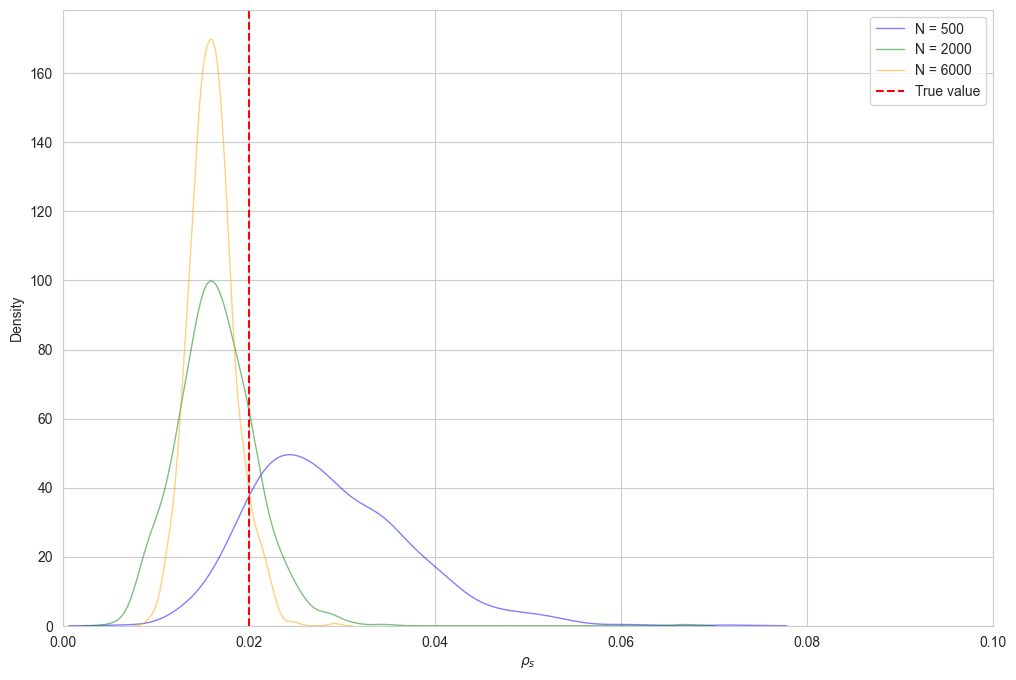

In [66]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta_trained_500_numpy[:, 0], label='N = 500', color='blue', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_2000_numpy[:, 0], label='N = 2000', color='green', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_6000_numpy[:, 0], label='N = 6000', color='orange', linewidth=1, alpha=0.5)
plt.axvline(x=0.02, color='red', linestyle='dashed', label='True value')
plt.xlabel(r'$\rho_s$')
plt.xlim(0.0, 0.1)
plt.legend()
plt.show()

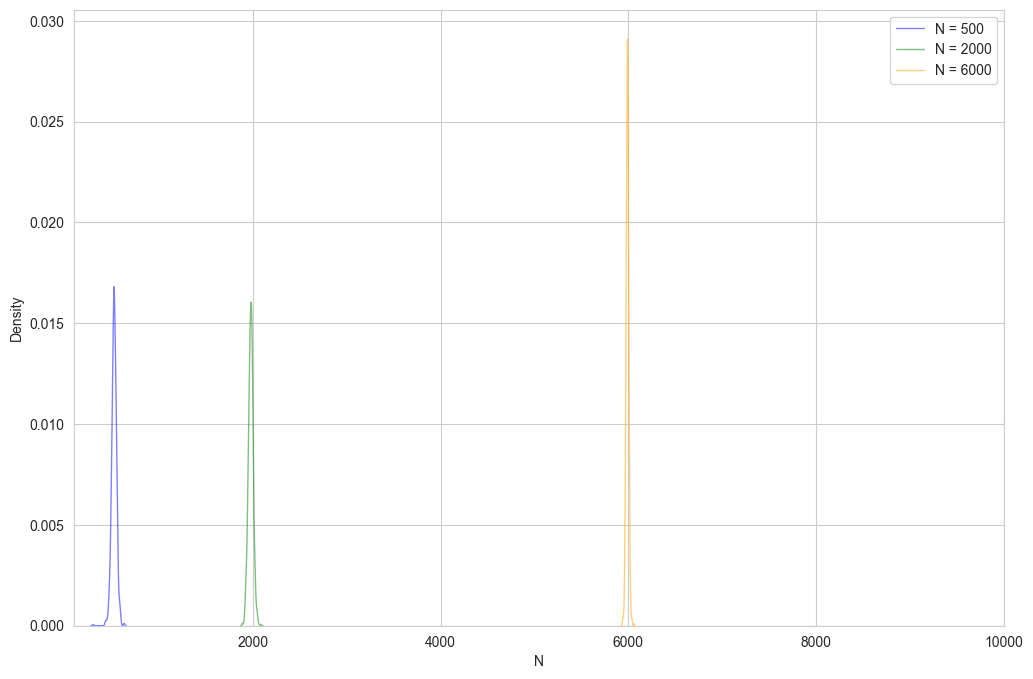

In [67]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta_trained_500_numpy[:, 1], label='N = 500', color='blue', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_2000_numpy[:, 1], label='N = 2000', color='green', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_6000_numpy[:, 1], label='N = 6000', color='orange', linewidth=1, alpha=0.5)
plt.xlabel('N')
plt.xlim(100.0, 10000.0)
plt.legend()
plt.show()

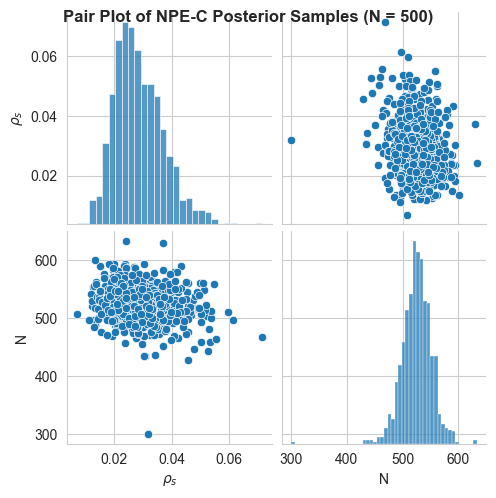

In [68]:
df_500 = pd.DataFrame(theta_trained_500_numpy, columns=[r"$\rho_s$", "N"])
sns.pairplot(df_500)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 500)', fontsize=12, fontweight='bold')
plt.show()

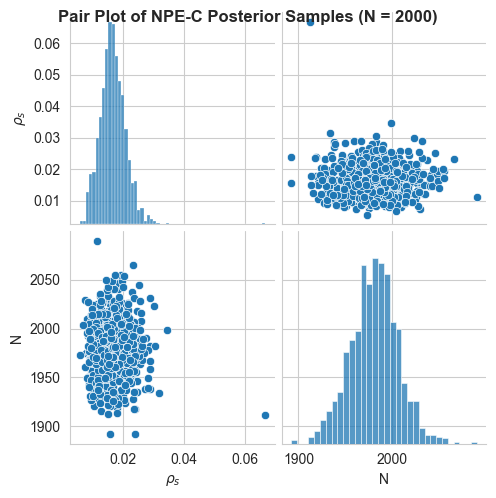

In [69]:
df_2000 = pd.DataFrame(theta_trained_2000_numpy, columns=[r"$\rho_s$", "N"])
sns.pairplot(df_2000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 2000)', fontsize=12, fontweight='bold')
plt.show()

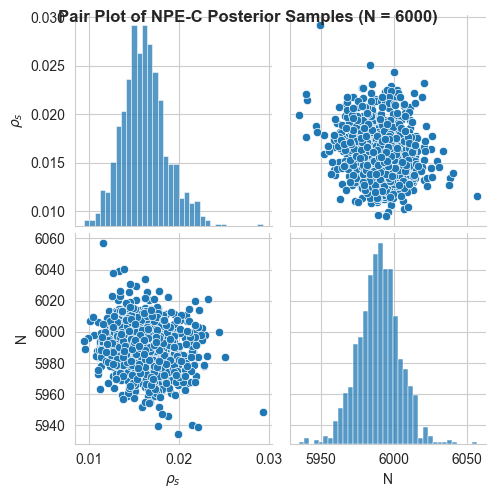

In [70]:
df_6000 = pd.DataFrame(theta_trained_6000_numpy, columns=[r"$\rho_s$", "N"])
sns.pairplot(df_6000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 6000)', fontsize=12, fontweight='bold')
plt.show()

#### ClonalOrigin observations

In [71]:
theta_trained_500 = posterior3.sample((num_posterior_samples,), x=CO_x_500[all_col])
theta_trained_500_numpy = theta_trained_500.cpu().numpy()

1099it [00:00, 28451.84it/s]            


In [72]:
theta_trained_2000 = posterior3.sample((num_posterior_samples,), x=CO_x_2000[all_col])
theta_trained_2000_numpy = theta_trained_2000.cpu().numpy()

1096it [00:00, 39661.08it/s]            


In [73]:
theta_trained_6000 = posterior3.sample((num_posterior_samples,), x=CO_x_6000[all_col])
theta_trained_6000_numpy = theta_trained_6000.cpu().numpy()

1099it [00:00, 39448.35it/s]            


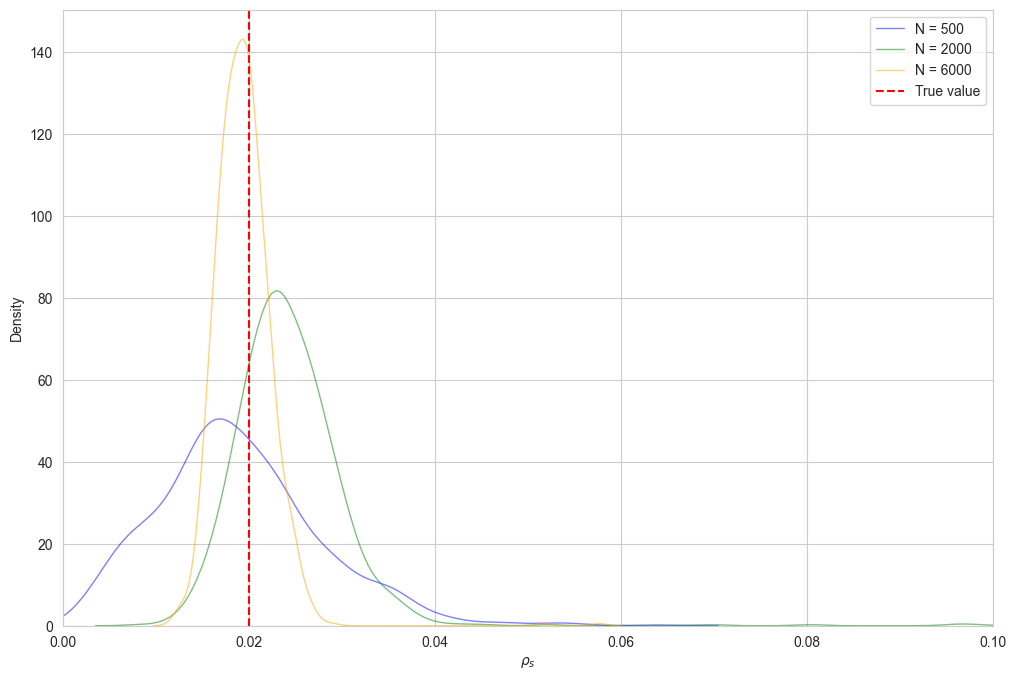

In [74]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta_trained_500_numpy[:, 0], label='N = 500', color='blue', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_2000_numpy[:, 0], label='N = 2000', color='green', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_6000_numpy[:, 0], label='N = 6000', color='orange', linewidth=1, alpha=0.5)
plt.axvline(x=0.02, color='red', linestyle='dashed', label='True value')
plt.xlabel(r'$\rho_s$')
plt.xlim(0.0, 0.1)
plt.legend()
plt.show()

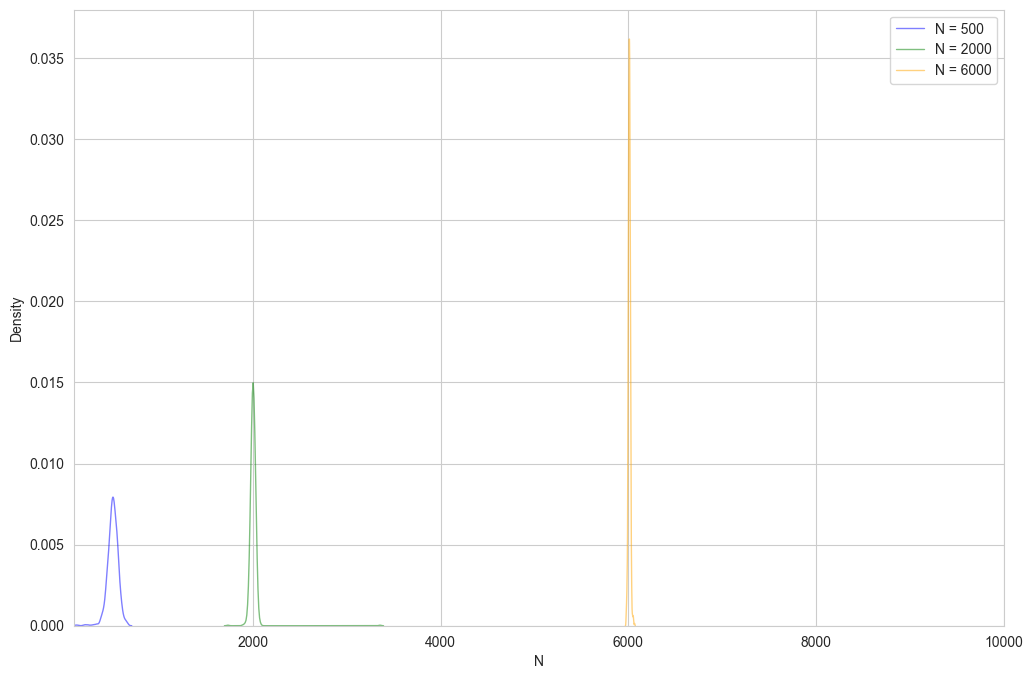

In [75]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta_trained_500_numpy[:, 1], label='N = 500', color='blue', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_2000_numpy[:, 1], label='N = 2000', color='green', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_6000_numpy[:, 1], label='N = 6000', color='orange', linewidth=1, alpha=0.5)
plt.xlabel('N')
plt.xlim(100.0, 10000.0)
plt.legend()
plt.show()

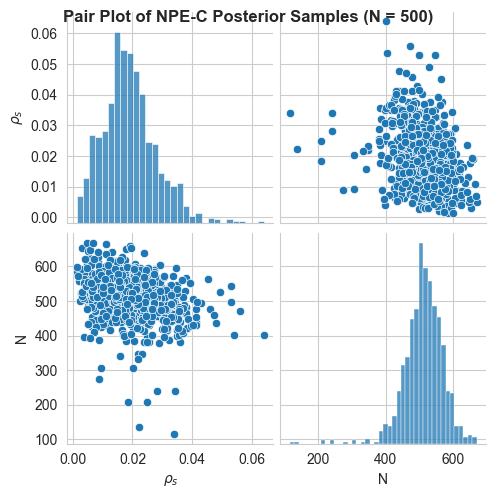

In [76]:
df_500 = pd.DataFrame(theta_trained_500_numpy, columns=[r"$\rho_s$", "N"])
sns.pairplot(df_500)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 500)', fontsize=12, fontweight='bold')
plt.show()

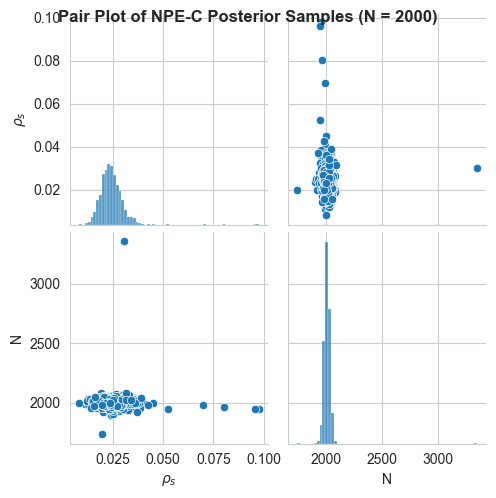

In [77]:
df_2000 = pd.DataFrame(theta_trained_2000_numpy, columns=[r"$\rho_s$", "N"])
sns.pairplot(df_2000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 2000)', fontsize=12, fontweight='bold')
plt.show()

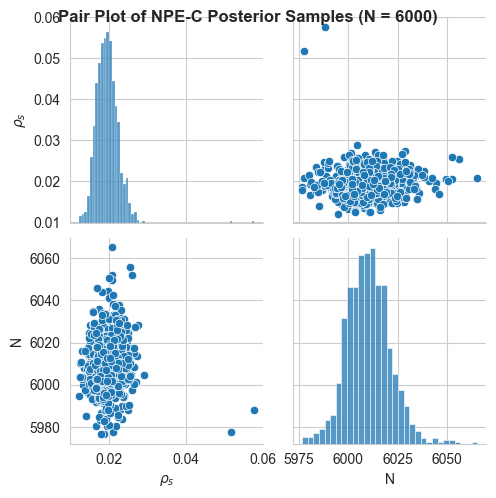

In [78]:
df_6000 = pd.DataFrame(theta_trained_6000_numpy, columns=[r"$\rho_s$", "N"])
sns.pairplot(df_6000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 6000)', fontsize=12, fontweight='bold')
plt.show()